# 📊 RRT vs RRT*

В этом ноутбуке проводится сравнение RRT и RRT* на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить RRT с RRT*

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Метрики записываются в CSV файл.
3. Максимально допустимые углы вперед/назад и вбок = 30 градусам
4. Всего 10 запусков

#### 📌 Важно

Так как число гауссов и размер карты не менятеся в экспериментах, то их можно грубо сравнить сравнить по средним метрикам, но только если было большое число запусков.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод
4. Парное сравнение
- Собрать парный датасет (RRT* vs RRT)
- В чем RRT* лучше RRT?
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/rrt.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,continuous,RRT,714.097,97,551,1899.63,1675,1,4,4,29.7420,29.4463
1,continuous,RRT*,201380.000,82,16753,1440.58,1167,1,4,4,27.9674,28.1733
2,continuous,RRT,450.853,96,294,1877.19,1688,1,4,4,28.9118,27.3041
3,continuous,RRT*,195727.000,77,16907,1446.55,1192,1,2,2,28.8801,28.3895
4,continuous,RRT,4253.370,102,5712,1967.56,1728,1,2,2,28.9274,28.9922


In [2]:
graph = df[df["environment"] == "continuous"]
success = (
    graph.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
RRT             10     10   1.0      100.0
RRT*            10     10   1.0      100.0


### 2) Небольшая очистка/подготовка

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               20 non-null     object 
 1   algorithmName             20 non-null     object 
 2   executionTimeMs           20 non-null     float64
 3   pathNodes                 20 non-null     int64  
 4   expandedNodes             20 non-null     int64  
 5   euclideanLength           20 non-null     float64
 6   pixelLength               20 non-null     int64  
 7   pathFound                 20 non-null     int64  
 8   minObstacleDistance       20 non-null     int64  
 9   minObstacleDistancePixel  20 non-null     int64  
 10  maxSideAngle              20 non-null     float64
 11  maxUpDownAngle            20 non-null     float64
dtypes: float64(4), int64(6), object(2)
memory usage: 2.0+ KB


In [4]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [6]:
# разделяем по алгоритмам
rrt = graph[graph["algorithmName"] == "RRT"].reset_index(drop=True)
rrt_star = graph[graph["algorithmName"] == "RRT*"].reset_index(drop=True)

# проверяем что строки совпадают по run-логике
n = min(len(rrt), len(rrt_star))

rrt = rrt.iloc[:n]
rrt_star = rrt_star.iloc[:n]

In [7]:
mask = (
    (rrt["pathFound"] == 1) &
    (rrt_star["pathFound"] == 1)
)

rrt = rrt[mask].reset_index(drop=True)
rrt_star = rrt_star[mask].reset_index(drop=True)

In [8]:
graph_ok = pd.concat([rrt, rrt_star], ignore_index=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
                     mean      median       std         min        max
algorithmName                                                         
RRT              1180.126     630.293  1217.470     396.504    4253.37
RRT*           192249.600  192334.000  4309.179  186242.000  201380.00


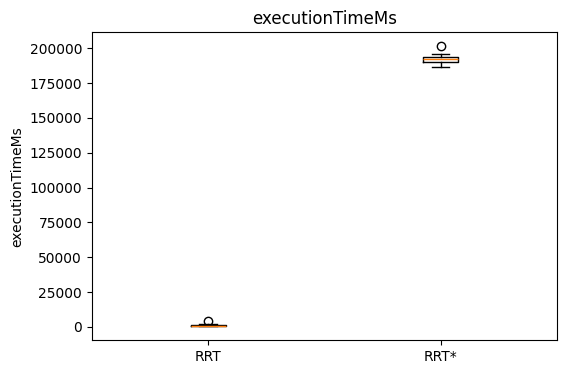


=========== expandedNodes ===========
                  mean   median       std    min    max
algorithmName                                          
RRT             1265.1    506.5  1693.617    294   5712
RRT*           16665.7  16732.0   191.241  16282  16907


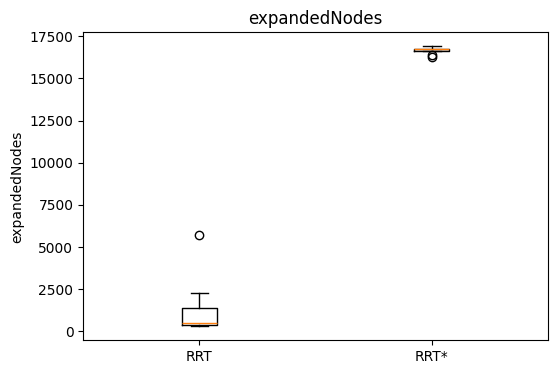


=========== pathNodes ===========
               mean  median    std  min  max
algorithmName                               
RRT            92.7    90.5  6.255   85  102
RRT*           79.3    78.5  4.057   74   87


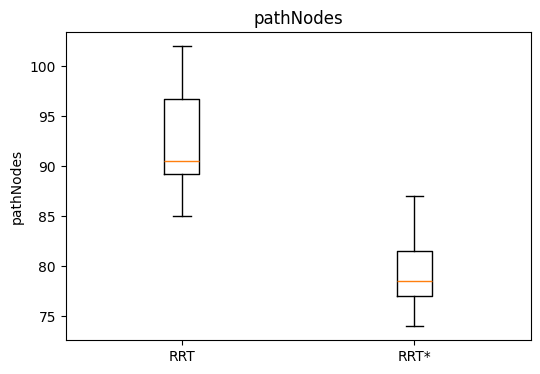


=========== euclideanLength ===========
                   mean   median      std      min      max
algorithmName                                              
RRT            1805.638  1772.41  123.982  1651.87  2000.08
RRT*           1441.852  1441.65    6.929  1428.54  1454.28


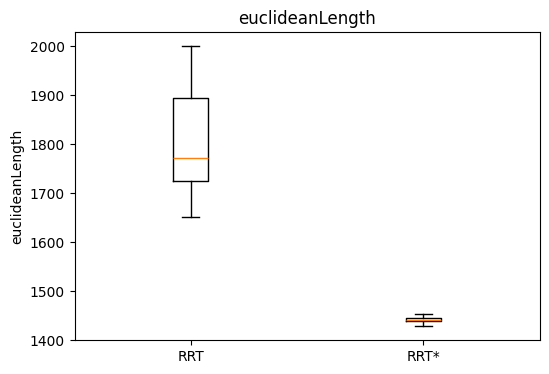


=========== pixelLength ===========
                 mean  median      std   min   max
algorithmName                                     
RRT            1580.3  1535.0  127.742  1411  1781
RRT*           1173.8  1173.0   19.999  1140  1213


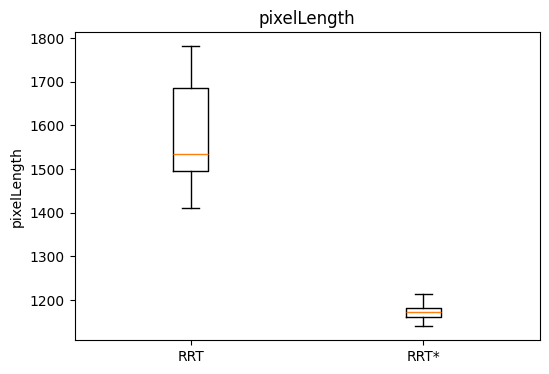


=========== minObstacleDistance ===========
               mean  median    std  min  max
algorithmName                               
RRT             3.6     4.0  0.843    2    4
RRT*            3.4     4.0  0.966    2    4


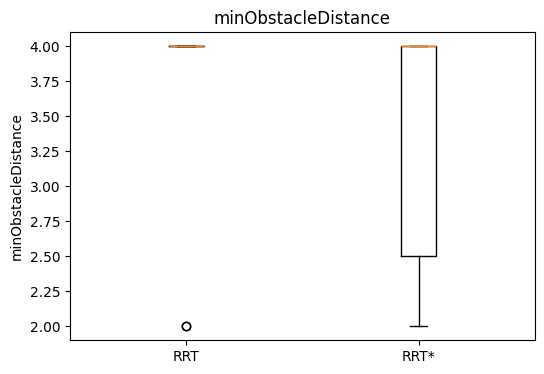


=========== minObstacleDistancePixel ===========
               mean  median    std  min  max
algorithmName                               
RRT             3.6     4.0  0.843    2    4
RRT*            3.4     4.0  0.966    2    4


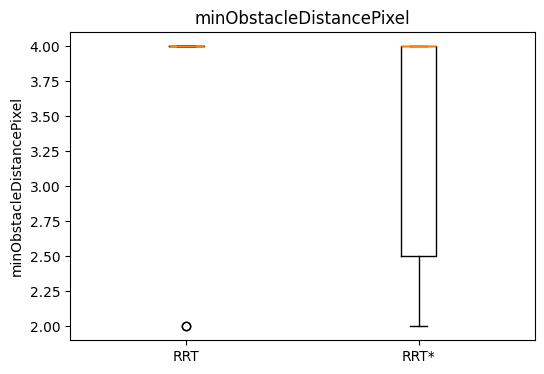


=========== maxSideAngle ===========
                 mean  median    std     min     max
algorithmName                                       
RRT            29.030  29.044  0.618  27.924  29.781
RRT*           29.429  29.687  0.632  27.967  29.961


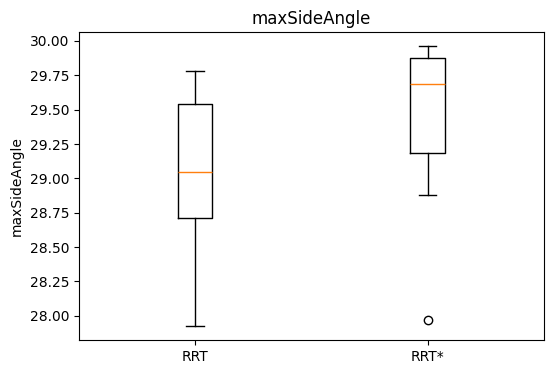


=========== maxUpDownAngle ===========
                 mean  median    std     min     max
algorithmName                                       
RRT            25.278  26.237  3.848  19.218  29.446
RRT*           25.250  28.209  5.952  12.973  29.986


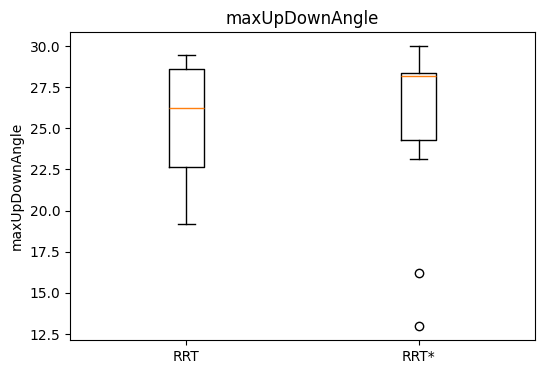

In [9]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        graph_ok.groupby("algorithmName")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        rrt[metric],
        rrt_star[metric]
    ], tick_labels=["RRT", "RRT*"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Оба алгоритма во всех проведённых испытаниях успешно находили путь. При этом RRT выполнялся значительно быстрее, однако получаемые маршруты были менее оптимальными. RRT* строил более короткие и качественные пути за счёт процедуры переподключения вершин, но требовал существенно большего времени вычислений и обрабатывал значительно большее число узлов. При этом расстояние до препятствий и ограничения по углам движения у обоих алгоритмов оказались сопоставимыми. Следует отметить, что в данной работе реализована базовая версия RRT* без специализированных оптимизаций. Существуют известные методы ускорения (например, эффективный поиск ближайших соседей, ограничение радиуса переподключения, отложенная проверка коллизий и другие), позволяющие уменьшить время работы примерно на порядок и более без существенного ухудшения качества построенного пути.

#### RRT* vs RRT

Подготовка метрик


=== time_ratio ===
mean      0.006
median    0.003
std       0.006
min       0.002
max       0.022
Name: time_ratio, dtype: float64


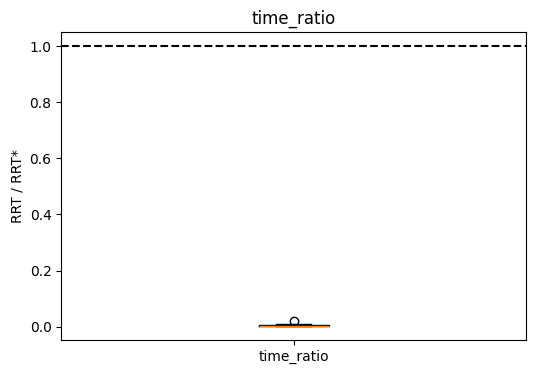


=== expandedNodes_ratio ===
mean      0.076
median    0.030
std       0.102
min       0.017
max       0.343
Name: expandedNodes_ratio, dtype: float64


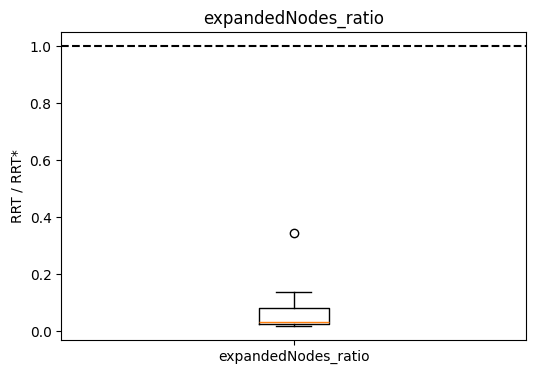


=== path_nodes_ratio ===
mean      1.170
median    1.164
std       0.079
min       1.012
max       1.308
Name: path_nodes_ratio, dtype: float64


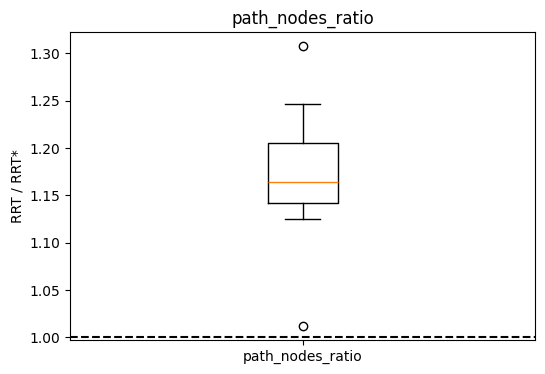


=== euclid_ratio ===
mean      1.252
median    1.237
std       0.087
min       1.144
max       1.386
Name: euclid_ratio, dtype: float64


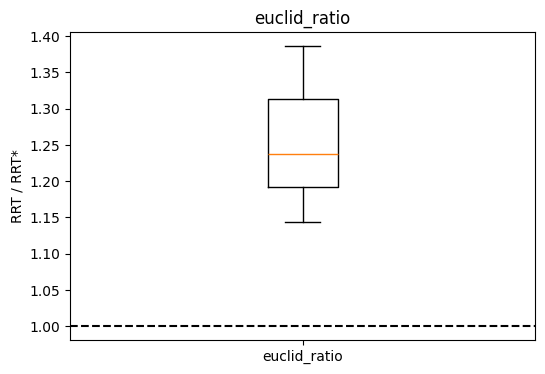


=== pixel_ratio ===
mean      1.347
median    1.334
std       0.110
min       1.206
max       1.504
Name: pixel_ratio, dtype: float64


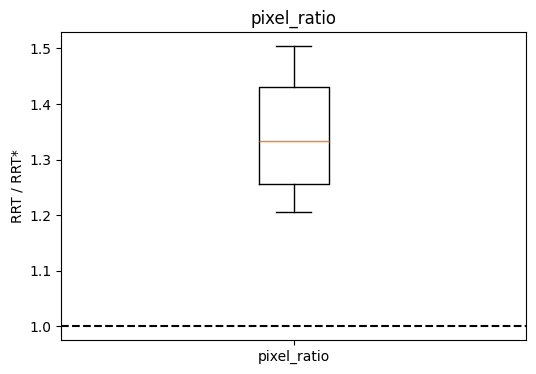

In [10]:
ratios = {
    "time_ratio": rrt["executionTimeMs"].to_numpy() / rrt_star["executionTimeMs"].to_numpy(),
    "expandedNodes_ratio": rrt["expandedNodes"].to_numpy() / rrt_star["expandedNodes"].to_numpy(),
    "path_nodes_ratio": rrt["pathNodes"].to_numpy() / rrt_star["pathNodes"].to_numpy(),
    "euclid_ratio": rrt["euclideanLength"].to_numpy() / rrt_star["euclideanLength"].to_numpy(),
    "pixel_ratio": rrt["pixelLength"].to_numpy() / rrt_star["pixelLength"].to_numpy(),
}

ratio_df = pd.DataFrame(ratios)

for name in ratio_df.columns:
    print(f"\n\033[1m=== {name} ===\033[0m")

    summary = ratio_df[name].agg(["mean", "median", "std", "min", "max"]).round(3)
    print(summary)

    plt.figure(figsize=(6, 4))

    plt.boxplot([ratio_df[name]], tick_labels=[name])
    plt.axhline(1.0, linestyle="--", color="black")

    plt.title(name)
    plt.ylabel("RRT / RRT*")

    plt.show()

#### Вывод

По результатам экспериментов RRT в среднем работал примерно в 170 раз быстрее, чем реализованная версия RRT*. При этом RRT* исследовал приблизительно в 13 раз больше вершин, однако благодаря этому строил пути лучшего качества: среднее число вершин в маршруте уменьшилось примерно на 17%, евклидова длина пути — примерно на 25%, а фактическая длина пути по пикселям — примерно на 35%. Таким образом, RRT демонстрирует значительно более высокую скорость построения пути, тогда как RRT* достигает более высокого качества маршрута ценой существенно больших вычислительных затрат. Следует отметить, что в данной работе использована базовая реализация RRT* без оптимизаций. Применение эффективных структур данных и известных методов ускорения позволяет на практике сократить время работы алгоритма примерно на порядок и более, сохранив его преимущества по качеству построенного пути.